In [49]:
import pandas as pd
import re
from io import StringIO
file_path = "raw_data.txt"

cleaned_rows = []

with open(file_path, "r") as f:
    for line in f:
        if "->" in line:
            line = line.split("->")[1].strip()
        else:
            line = line.strip()
        if line:
            cleaned_rows.append(line)

cleaned_text = "\n".join(cleaned_rows)
data = pd.read_csv(
    StringIO(cleaned_text),
    header=None,
    names=["time_ms", "raw_adc", "moisture_percent", "label"]
)
data = data.apply(pd.to_numeric, errors='coerce')
data = data.dropna()
data = data.reset_index(drop=True)
data.to_csv("processed_soil_data.csv", index=False)
print("Preprocessing complete.")
print(data.head())
print("\nTotal samples:", len(data))

Preprocessing complete.
   time_ms  raw_adc  moisture_percent  label
0    18020     2652               0.0      1
1    19020     2672               0.0      1
2    20020     2653               0.0      1
3    21020     2649               0.0      1
4    22020     2653               0.0      1

Total samples: 2635


In [50]:
import pandas as pd
data = pd.read_csv("processed_soil_data.csv")

print("\nClass Distribution:")
print(data["label"].value_counts())


Class Distribution:
label
0    1790
1     845
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split
X = data[["raw_adc", "moisture_percent"]]
y = data["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2108
Testing samples: 527


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

KNN
Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [56]:
print("Model Comparison:")
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Model Comparison:
KNN Accuracy: 0.9981024667931688
Decision Tree Accuracy: 0.9981024667931688
Logistic Regression Accuracy: 0.9981024667931688


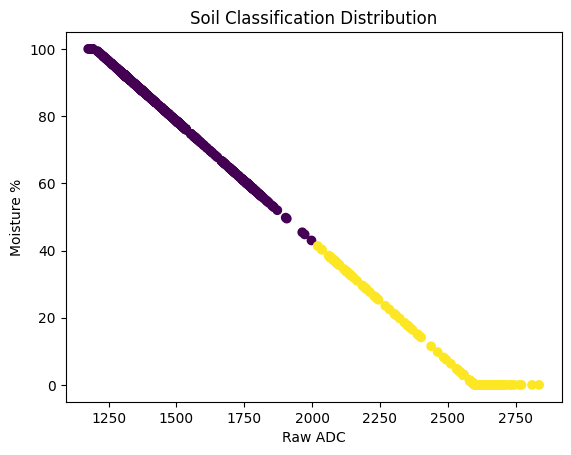

In [57]:
import matplotlib.pyplot as plt

plt.scatter(data["raw_adc"], data["moisture_percent"], c=data["label"])
plt.xlabel("Raw ADC")
plt.ylabel("Moisture %")
plt.title("Soil Classification Distribution")
plt.show()

In [58]:
from sklearn.model_selection import cross_val_score

models = {
    "KNN": knn,
    "Logistic": lr,
    "Decision Tree": dt
}

print("\nCross Validation")

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled if name!="Decision Tree" else X_train, y_train, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")



Cross Validation
KNN CV Accuracy: 0.9995
Logistic CV Accuracy: 1.0000
Decision Tree CV Accuracy: 0.9995


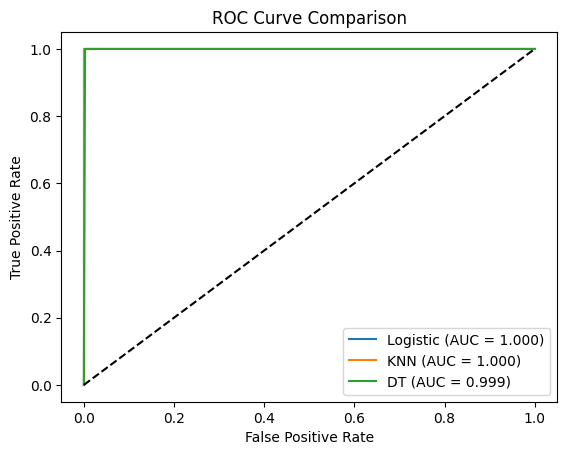

In [59]:
from sklearn.metrics import roc_curve, auc

plt.figure()

lr_probs = lr.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label="Logistic (AUC = %.3f)" % auc(fpr_lr, tpr_lr))

knn_probs = knn.predict_proba(X_test_scaled)[:,1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)
plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = %.3f)" % auc(fpr_knn, tpr_knn))

dt_probs = dt.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr_dt, tpr_dt, label="DT (AUC = %.3f)" % auc(fpr_dt, tpr_dt))

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Results
Accuracy: 0.9981024667931688
[[358   1]
 [  0 168]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_dt = grid.best_estimator_


Best Parameters: {'max_depth': 3, 'min_samples_split': 2}


In [62]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('lr', lr),
        ('rf', rf)
    ],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

ensemble_pred = ensemble.predict(X_test_scaled)

print("=== Ensemble Results ===")
print("Accuracy:", accuracy_score(y_test, ensemble_pred))


=== Ensemble Results ===
Accuracy: 0.9981024667931688


In [63]:
data = data.sort_values("time_ms").reset_index(drop=True)


In [64]:
data["time_diff"] = data["time_ms"].diff()


In [65]:
data["moisture_diff"] = data["moisture_percent"].diff()


In [66]:
data["drying_rate"] = data["moisture_diff"] / data["time_diff"]


In [67]:
data = data.dropna()
data = data[data["time_diff"] > 0]


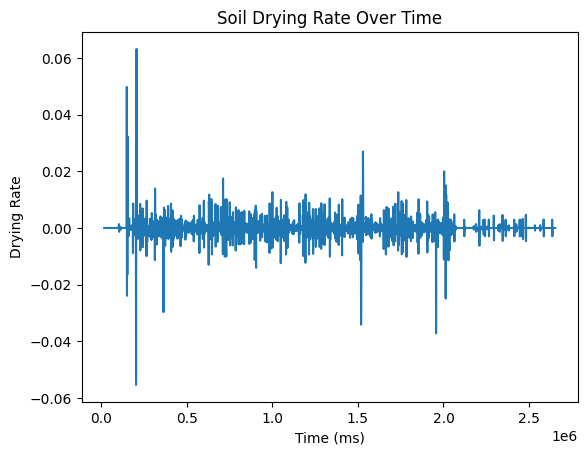

In [68]:
import matplotlib.pyplot as plt

plt.plot(data["time_ms"], data["drying_rate"])
plt.xlabel("Time (ms)")
plt.ylabel("Drying Rate")
plt.title("Soil Drying Rate Over Time")
plt.show()


In [69]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# convert to numpy arrays
y_train = y_train.values
y_test = y_test.values

def knn(X_train, y_train, X_test, k=5):
    predictions = []

    for x in X_test:
        distances = np.sqrt(np.sum((X_train - x)**2, axis=1))
        k_idx = np.argsort(distances)[:k]
        k_labels = y_train[k_idx]
        pred = Counter(k_labels).most_common(1)[0][0]
        predictions.append(pred)

    return np.array(predictions)

knn_pred = knn(X_train_scaled, y_train, X_test_scaled, k=5)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [71]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Gini impurity
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return 1 - np.sum(prob ** 2)

# Split dataset
def split_dataset(X, y, feature, threshold):
    left = X[:, feature] <= threshold
    right = X[:, feature] > threshold
    return X[left], X[right], y[left], y[right]

# Find best split
def best_split(X, y):
    best_feature, best_threshold = None, None
    best_gini = float("inf")

    n_features = X.shape[1]

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])

        for threshold in thresholds:
            X_l, X_r, y_l, y_r = split_dataset(X, y, feature, threshold)

            if len(y_l) == 0 or len(y_r) == 0:
                continue

            g = (len(y_l)/len(y))*gini(y_l) + (len(y_r)/len(y))*gini(y_r)

            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

# Build tree
def build_tree(X, y, depth=0, max_depth=4):

    if len(np.unique(y)) == 1 or depth >= max_depth:
        return np.bincount(y).argmax()

    feature, threshold = best_split(X, y)

    if feature is None:
        return np.bincount(y).argmax()

    X_l, X_r, y_l, y_r = split_dataset(X, y, feature, threshold)

    return {
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(X_l, y_l, depth+1, max_depth),
        "right": build_tree(X_r, y_r, depth+1, max_depth)
    }

# Predict one sample
def predict_sample(tree, x):
    if not isinstance(tree, dict):
        return tree

    if x[tree["feature"]] <= tree["threshold"]:
        return predict_sample(tree["left"], x)
    else:
        return predict_sample(tree["right"], x)

# Predict dataset
def predict(tree, X):
    return np.array([predict_sample(tree, x) for x in X])

# Train tree
tree = build_tree(X_train, y_train, max_depth=4)

# Predict
dt_pred = predict(tree, X_test)

print("Raw Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Raw Decision Tree
Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527



In [72]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure numpy arrays
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Training with gradient descent
def train_logistic_regression(X, y, lr=0.01, epochs=1000):

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):

        linear = np.dot(X, weights) + bias
        predictions = sigmoid(linear)

        dw = (1/n_samples) * np.dot(X.T, (predictions - y))
        db = (1/n_samples) * np.sum(predictions - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias

# Prediction
def predict(X, weights, bias):

    linear = np.dot(X, weights) + bias
    probs = sigmoid(linear)

    return (probs >= 0.5).astype(int)

# Train
weights, bias = train_logistic_regression(X_train_scaled, y_train)

# Predict
lr_pred = predict(X_test_scaled, weights, bias)

print("Raw Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Raw Logistic Regression
Accuracy: 0.9981024667931688
Confusion Matrix:
 [[358   1]
 [  0 168]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       0.99      1.00      1.00       168

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527

